In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [ ]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv('fertilizer_recommendation.csv')
df.head()

Saving fertilizer_recommendation.csv to fertilizer_recommendation (2).csv


,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Nitrogen_Level,Phosphorus_Level,Potassium_Level,Temperature,Humidity,Rainfall,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Previous_Crop,Region,Fertilizer_Used_Last_Season,Yield_Last_Season,Recommended_Fertilizer
0,Clay,6.07,34.98,0.32,1.87,61,44,84,19.84,83.31,1693.22,Cotton,Harvest,Kharif,Canal,Wheat,South,297.15,1.19,MOP
1,Silt,6.39,47.34,0.28,0.21,59,56,18,24.40,46.27,1030.21,Maize,Vegetative,Kharif,Sprinkler,Potato,Central,77.17,4.40,Urea
2,Sandy,7.92,38.13,0.99,1.88,43,21,119,24.82,71.86,1166.16,Cotton,Flowering,Kharif,Rainfed,Tomato,South,128.93,7.21,Urea
3,Clay,5.86,14.17,1.46,0.36,88,46,34,27.87,53.23,2881.83,Wheat,Flowering,Zaid,Sprinkler,Potato,West,233.96,1.85,MOP
4,Clay,7.98,19.28,0.85,2.16,104,53,98,24.17,51.87,714.84,Potato,Sowing,Kharif,Rainfed,Maize,East,214.39,7.36,Zinc Sulphate


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Soil_Type                    10000 non-null  object 
 1   Soil_pH                      10000 non-null  float64
 2   Soil_Moisture                10000 non-null  float64
 3   Organic_Carbon               10000 non-null  float64
 4   Electrical_Conductivity      10000 non-null  float64
 5   Nitrogen_Level               10000 non-null  int64  
 6   Phosphorus_Level             10000 non-null  int64  
 7   Potassium_Level              10000 non-null  int64  
 8   Temperature                  10000 non-null  float64
 9   Humidity                     10000 non-null  float64
 10  Rainfall                     10000 non-null  float64
 11  Crop_Type                    10000 non-null  object 
 12  Crop_Growth_Stage            10000 non-null  object 
 13  Season           

In [ ]:
df.shape

(10000, 20)

In [ ]:
df.isnull().sum()

,0
Soil_Type,0
Soil_pH,0
Soil_Moisture,0
Organic_Carbon,0
Electrical_Conductivity,0
Nitrogen_Level,0
Phosphorus_Level,0
Potassium_Level,0
Temperature,0
Humidity,0


In [ ]:
df['Recommended_Fertilizer'].value_counts()

,count
Recommended_Fertilizer,
Urea,3101
DAP,2920
MOP,1408
Compost,996
Zinc Sulphate,752
NPK,641
SSP,182


<Axes: xlabel='count', ylabel='Recommended_Fertilizer'>

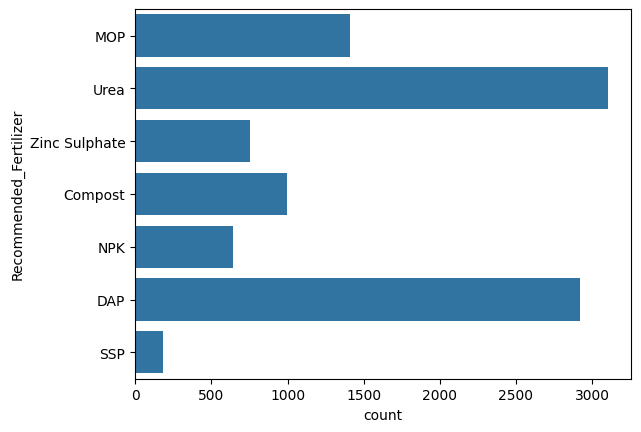

In [ ]:
sns.countplot(y='Recommended_Fertilizer', data=df)

In [ ]:
le_soil = LabelEncoder()
le_crop = LabelEncoder()
le_fert = LabelEncoder()
le_growth_stage = LabelEncoder()
le_season = LabelEncoder()
le_irrigation = LabelEncoder()
le_previous_crop = LabelEncoder()
le_region = LabelEncoder()

df['Soil_Type'] = le_soil.fit_transform(df['Soil_Type'])
df['Crop_Type'] = le_crop.fit_transform(df['Crop_Type'])
df['Recommended_Fertilizer'] = le_fert.fit_transform(df['Recommended_Fertilizer'])  # this is your target
df['Crop_Growth_Stage'] = le_growth_stage.fit_transform(df['Crop_Growth_Stage'])
df['Season'] = le_season.fit_transform(df['Season'])
df['Irrigation_Type'] = le_irrigation.fit_transform(df['Irrigation_Type'])
df['Previous_Crop'] = le_previous_crop.fit_transform(df['Previous_Crop'])
df['Region'] = le_region.fit_transform(df['Region'])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Soil_Type                    10000 non-null  int64  
 1   Soil_pH                      10000 non-null  float64
 2   Soil_Moisture                10000 non-null  float64
 3   Organic_Carbon               10000 non-null  float64
 4   Electrical_Conductivity      10000 non-null  float64
 5   Nitrogen_Level               10000 non-null  int64  
 6   Phosphorus_Level             10000 non-null  int64  
 7   Potassium_Level              10000 non-null  int64  
 8   Temperature                  10000 non-null  float64
 9   Humidity                     10000 non-null  float64
 10  Rainfall                     10000 non-null  float64
 11  Crop_Type                    10000 non-null  int64  
 12  Crop_Growth_Stage            10000 non-null  int64  
 13  Season           

In [ ]:
X = df.drop('Recommended_Fertilizer', axis=1)
y = df['Recommended_Fertilizer']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

In [ ]:
df['Recommended_Fertilizer'].value_counts(normalize=True) * 100

,proportion
Recommended_Fertilizer,
5,31.01
1,29.20
2,14.08
0,9.96
6,7.52
3,6.41
4,1.82


In [ ]:
smote = SMOTE(random_state=42, k_neighbors=3)  # or even 2, depending on how few samples class 4 has

In [ ]:
counts = df['Recommended_Fertilizer'].value_counts()
counts.min()  # if this is less than 6, reduce k_neighbors in SMOTE

182

In [ ]:
y_train_bal.value_counts()


,count
Recommended_Fertilizer,
5,2481
1,2481
2,2481
4,2481
3,2481
6,2481
0,2481


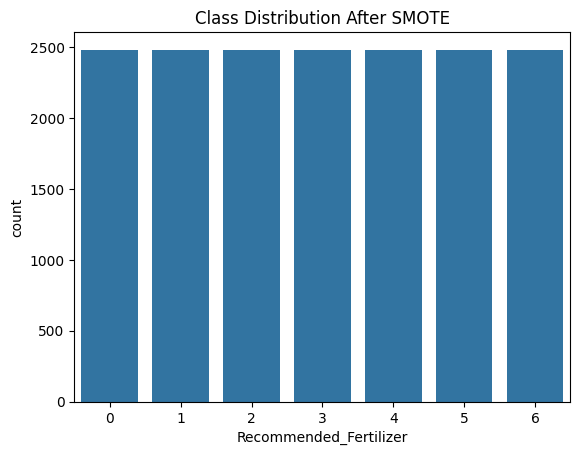

In [ ]:
sns.countplot(x=y_train_bal)
plt.title('Class Distribution After SMOTE')
plt.show()

In [ ]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train_bal, y_train_bal)
rf_preds = rf.predict(X_test_scaled)

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_bal, y_train_bal)
knn_preds = knn.predict(X_test_scaled)

In [ ]:
xgb = XGBClassifier(objective='multi:softmax', num_class=len(y.unique()), random_state=42)
xgb.fit(X_train_bal, y_train_bal)
xgb_preds = xgb.predict(X_test_scaled)

In [ ]:
for name, preds in [('Random Forest', rf_preds), ('KNN', knn_preds), ('XGBoost', xgb_preds)]:
    print(f"--- {name} ---")
    print("Accuracy:", accuracy_score(y_test, preds))
    print(classification_report(y_test, preds))

--- Random Forest ---
Accuracy: 0.8715
              precision    recall  f1-score   support

           0       0.86      0.80      0.83       199
           1       1.00      0.92      0.96       584
           2       0.93      0.85      0.89       282
           3       0.80      0.70      0.75       128
           4       0.17      0.46      0.25        37
           5       1.00      0.93      0.96       620
           6       0.54      0.81      0.65       150

    accuracy                           0.87      2000
   macro avg       0.76      0.78      0.75      2000
weighted avg       0.91      0.87      0.89      2000

--- KNN ---
Accuracy: 0.433
              precision    recall  f1-score   support

           0       0.30      0.49      0.37       199
           1       0.70      0.49      0.57       584
           2       0.41      0.46      0.43       282
           3       0.18      0.41      0.25       128
           4       0.04      0.19      0.07        37
           

In [ ]:
import joblib

joblib.dump(xgb, 'fertilizer_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le_soil, 'le_soil.pkl')
joblib.dump(le_crop, 'le_crop.pkl')
joblib.dump(le_fert, 'le_fert.pkl')

# if you have encoders for the other categorical columns too:
joblib.dump(le_growth_stage, 'le_growth_stage.pkl')
joblib.dump(le_season, 'le_season.pkl')
joblib.dump(le_irrigation, 'le_irrigation.pkl')
joblib.dump(le_region, 'le_region.pkl')

['le_region.pkl']

In [ ]:
from google.colab import files

files.download('fertilizer_model.pkl')
files.download('scaler.pkl')
files.download('le_soil.pkl')
files.download('le_crop.pkl')
files.download('le_fert.pkl')


files.download('le_growth_stage.pkl')
files.download('le_season.pkl')
files.download('le_irrigation.pkl')
files.download('le_region.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>